<a href="https://colab.research.google.com/github/atkhushboo/subscriber-churn-analysis-python/blob/main/fitly_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
#Fitly Data Analysis....

In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
#import libraries ...

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
import os
os.listdir()

['.config', 'drive', 'sample_data']

In [81]:
# read CSV files.....

account_info = pd.read_csv("/content/drive/MyDrive/Fitly/da_fitly_account_info.csv")
customer_support = pd.read_csv("/content/drive/MyDrive/Fitly/da_fitly_customer_support.csv")
user_activity = pd.read_csv("/content/drive/MyDrive/Fitly/da_fitly_user_activity.csv")

In [82]:
# account info data view
account_info.head()


,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,C10003,user10003@example.com,Michigan,Free,0,NaN
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN


In [83]:
# Customer support data view
print(customer_support.head())

                  ticket_time  user_id channel      topic  \
0  2025-06-13 05:55:17.154573    10125    chat  technical   
1  2025-08-06 13:21:54.539551    10109    chat    account   
2  2025-08-22 12:39:35.718663    10149    chat  technical   
3  2025-06-07 02:49:46.986055    10268   phone    account   
4  2025-07-25 00:24:38.945079    10041   phone      other   

   resolution_time_hours  state                          comments  
0                  11.48      1                               NaN  
1                   1.01      0                               NaN  
2                  10.09      0  Erase my data from your systems.  
3                   9.10      1                               NaN  
4                   2.28      1                               NaN  


In [84]:
# user activity data view

user_activity.head()

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


In [85]:
# Data Size ......
print('account info:- ',account_info.shape)
print('customer support:- ',customer_support.shape)
print('user sctivity:- ',user_activity.shape)


account info:-  (400, 6)
customer support:-  (918, 7)
user sctivity:-  (445, 3)


In [86]:
# Basic INFOMATION of data
account_info.info()
print("-" * 50)

customer_support.info()
print("-" * 50)

user_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    object 
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    object 
 3   topic                  918 non-null    object 
 4   resolution_ti

In [87]:
# dataset overview

account_info.describe(include='all')
customer_support.describe(include='all')
user_activity.describe(include='all')

,event_time,user_id,event_type
count,445,445.000000,445
unique,445,NaN,4
top,2025-07-18 10:09:46.737631,NaN,read_article
freq,1,NaN,125
mean,NaN,10198.930337,NaN
std,NaN,113.583807,NaN
min,NaN,10000.000000,NaN
25%,NaN,10110.000000,NaN
50%,NaN,10197.000000,NaN
75%,NaN,10294.000000,NaN


In [88]:
# Missing Values Check
print("Account Info")
print(account_info.isnull().sum())

print("\nCustomer Support")
print(customer_support.isnull().sum())

print("\nUser Activity")
print(user_activity.isnull().sum())

Account Info
customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64

Customer Support
ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64

User Activity
event_time    0
user_id       0
event_type    0
dtype: int64


In [89]:
# Duplicate values check

print("Account Info:", account_info.duplicated().sum())

print("customer support:",customer_support.duplicated().sum())

print("user activity:", user_activity.duplicated().sum())


Account Info: 0
customer support: 0
user activity: 0


In [90]:
print(customer_support["ticket_time"])

0      2025-06-13 05:55:17.154573
1      2025-08-06 13:21:54.539551
2      2025-08-22 12:39:35.718663
3      2025-06-07 02:49:46.986055
4      2025-07-25 00:24:38.945079
                  ...            
913    2025-06-05 23:09:46.282238
914    2025-08-19 11:03:30.765219
915    2025-08-07 13:17:13.090150
916    2025-07-06 11:28:27.421494
917    2025-11-28 17:25:17.874347
Name: ticket_time, Length: 918, dtype: object


In [91]:
print(user_activity['event_time'])

0      2025-09-08 15:05:39.422721
1      2025-09-08 08:15:05.264103
2      2025-11-14 06:28:35.207671
3      2025-08-20 16:53:38.682901
4      2025-07-24 16:47:31.728422
                  ...            
440    2025-10-22 12:09:09.477660
441    2025-09-22 18:28:07.618295
442    2025-07-28 14:52:16.311955
443    2025-11-27 13:38:32.371575
444    2025-07-18 10:09:46.737631
Name: event_time, Length: 445, dtype: object


In [92]:
customer_support['ticket_time'] = pd.to_datetime(customer_support['ticket_time'])
print(customer_support['ticket_time'])

0     2025-06-13 05:55:17.154573
1     2025-08-06 13:21:54.539551
2     2025-08-22 12:39:35.718663
3     2025-06-07 02:49:46.986055
4     2025-07-25 00:24:38.945079
                 ...            
913   2025-06-05 23:09:46.282238
914   2025-08-19 11:03:30.765219
915   2025-08-07 13:17:13.090150
916   2025-07-06 11:28:27.421494
917   2025-11-28 17:25:17.874347
Name: ticket_time, Length: 918, dtype: datetime64[ns]


In [93]:
user_activity['event_time']= pd.to_datetime(user_activity['event_time'])
print(user_activity['event_time'])

0     2025-09-08 15:05:39.422721
1     2025-09-08 08:15:05.264103
2     2025-11-14 06:28:35.207671
3     2025-08-20 16:53:38.682901
4     2025-07-24 16:47:31.728422
                 ...            
440   2025-10-22 12:09:09.477660
441   2025-09-22 18:28:07.618295
442   2025-07-28 14:52:16.311955
443   2025-11-27 13:38:32.371575
444   2025-07-18 10:09:46.737631
Name: event_time, Length: 445, dtype: datetime64[ns]


In [94]:
print(account_info['churn_status'].value_counts(dropna=False))

churn_status
NaN    286
Y      114
Name: count, dtype: int64


In [95]:
# Create a new customer ID column by removing the 'C' prefix for merging datasets.
account_info['user_id'] = account_info['customer_id'].str.replace('C', '').astype(int)
account_info.head()

,customer_id,email,state,plan,plan_list_price,churn_status,user_id
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y,10000
1,C10001,user10001@example.net,Louisiana,Basic,22,Y,10001
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN,10002
3,C10003,user10003@example.com,Michigan,Free,0,NaN,10003
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN,10004


In [96]:
# check Duplicate values
print("Account info duplicate records:- ",account_info['user_id'].duplicated().sum())
print("Customer support duplicate records: - ",customer_support['user_id'].duplicated().sum())
print("User activity duplicate records:- ",user_activity['user_id'].duplicated().sum())

Account info duplicate records:-  0
Customer support duplicate records: -  551
User activity duplicate records:-  199


In [97]:
# merging account_info and customer_support tables using left join

fitly_df_first = pd.merge(account_info,customer_support, on='user_id',how='left')
print(fitly_df_first.head(20))

   customer_id                  email         state_x        plan  \
0       C10000  user10000@example.com      New Jersey  Enterprise   
1       C10000  user10000@example.com      New Jersey  Enterprise   
2       C10000  user10000@example.com      New Jersey  Enterprise   
3       C10001  user10001@example.net       Louisiana       Basic   
4       C10001  user10001@example.net       Louisiana       Basic   
5       C10001  user10001@example.net       Louisiana       Basic   
6       C10001  user10001@example.net       Louisiana       Basic   
7       C10002  user10002@example.net        Oklahoma       Basic   
8       C10002  user10002@example.net        Oklahoma       Basic   
9       C10002  user10002@example.net        Oklahoma       Basic   
10      C10003  user10003@example.com        Michigan        Free   
11      C10004  user10004@example.com           Texas  Enterprise   
12      C10004  user10004@example.com           Texas  Enterprise   
13      C10004  user10004@example.

In [98]:
# merging fitly_df and user_activity tables using left join
fitly_df= pd.merge(fitly_df_first, user_activity,on='user_id',how='left')
print(fitly_df.shape)
print(fitly_df.head())

(1441, 15)
  customer_id                  email     state_x        plan  plan_list_price  \
0      C10000  user10000@example.com  New Jersey  Enterprise              105   
1      C10000  user10000@example.com  New Jersey  Enterprise              105   
2      C10000  user10000@example.com  New Jersey  Enterprise              105   
3      C10000  user10000@example.com  New Jersey  Enterprise              105   
4      C10000  user10000@example.com  New Jersey  Enterprise              105   

  churn_status  user_id                ticket_time channel    topic  \
0            Y    10000 2025-08-27 22:10:44.358592   email    other   
1            Y    10000 2025-08-27 22:10:44.358592   email    other   
2            Y    10000 2025-08-27 22:10:44.358592   email    other   
3            Y    10000 2025-07-27 11:51:43.108877    chat  account   
4            Y    10000 2025-07-27 11:51:43.108877    chat  account   

   resolution_time_hours  state_y comments                 event_time  \
0 

In [99]:
# verifying information

print(fitly_df.shape)

(1441, 15)


In [100]:
print(fitly_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            1441 non-null   object        
 1   email                  1441 non-null   object        
 2   state_x                1441 non-null   object        
 3   plan                   1441 non-null   object        
 4   plan_list_price        1441 non-null   int64         
 5   churn_status           301 non-null    object        
 6   user_id                1441 non-null   int64         
 7   ticket_time            1390 non-null   datetime64[ns]
 8   channel                1390 non-null   object        
 9   topic                  1390 non-null   object        
 10  resolution_time_hours  1390 non-null   float64       
 11  state_y                1390 non-null   float64       
 12  comments               67 non-null     object        
 13  eve

In [101]:
print(fitly_df.describe(include='all'))

       customer_id                  email state_x   plan  plan_list_price  \
count         1441                   1441    1441   1441      1441.000000   
unique         400                    400      50      4              NaN   
top         C10120  user10120@example.net   Texas  Basic              NaN   
freq            20                     20      57    447              NaN   
mean           NaN                    NaN     NaN    NaN        44.267176   
min            NaN                    NaN     NaN    NaN         0.000000   
25%            NaN                    NaN     NaN    NaN         0.000000   
50%            NaN                    NaN     NaN    NaN        24.000000   
75%            NaN                    NaN     NaN    NaN        78.000000   
max            NaN                    NaN     NaN    NaN       148.000000   
std            NaN                    NaN     NaN    NaN        46.134030   

       churn_status       user_id                    ticket_time channel  \

In [102]:
print(fitly_df[fitly_df['user_id']==10120])

    customer_id                  email        state_x  plan  plan_list_price  \
393      C10120  user10120@example.net  Massachusetts  Free                0   
394      C10120  user10120@example.net  Massachusetts  Free                0   
395      C10120  user10120@example.net  Massachusetts  Free                0   
396      C10120  user10120@example.net  Massachusetts  Free                0   
397      C10120  user10120@example.net  Massachusetts  Free                0   
398      C10120  user10120@example.net  Massachusetts  Free                0   
399      C10120  user10120@example.net  Massachusetts  Free                0   
400      C10120  user10120@example.net  Massachusetts  Free                0   
401      C10120  user10120@example.net  Massachusetts  Free                0   
402      C10120  user10120@example.net  Massachusetts  Free                0   
403      C10120  user10120@example.net  Massachusetts  Free                0   
404      C10120  user10120@example.net  

In [103]:
print(fitly_df['plan'].value_counts())

plan
Basic         447
Free          369
Enterprise    338
Pro           287
Name: count, dtype: int64


In [104]:
# Part 1: Univariate Analysis (single column).............

In [105]:
# Plan distribution

print(fitly_df['plan'].value_counts())

plan
Basic         447
Free          369
Enterprise    338
Pro           287
Name: count, dtype: int64


In [106]:
# Churn distribution

print(fitly_df['churn_status'].value_counts())

churn_status
Y    301
Name: count, dtype: int64


In [107]:
# Topic distribution

print(fitly_df['topic'].value_counts())

topic
billing      366
other        356
account      343
technical    325
Name: count, dtype: int64


In [108]:
# Channel distribution

print(fitly_df['channel'].value_counts())

channel
chat     468
email    438
phone    427
-         57
Name: count, dtype: int64


In [109]:
# Event type distribution

print(fitly_df['event_type'].value_counts())

event_type
read_article     308
watch_video      293
track_workout    261
share_workout    201
Name: count, dtype: int64


In [110]:
# Resolution time summary

print(fitly_df['resolution_time_hours'].describe(include='all'))

count    1390.000000
mean        9.458396
std         6.398738
min         0.520000
25%         4.980000
50%         8.370000
75%        11.515000
max        32.460000
Name: resolution_time_hours, dtype: float64


In [111]:
# part 2: - Bivariate Analysis (2 columns)......

In [112]:
# Plan vs Churn
print(fitly_df[['plan','churn_status']].value_counts())

plan        churn_status
Free        Y               108
Basic       Y                72
Enterprise  Y                63
Pro         Y                58
Name: count, dtype: int64


In [113]:
# Topic vs Churn

print(fitly_df[['topic','churn_status']].value_counts())


topic      churn_status
billing    Y               95
account    Y               68
other      Y               68
technical  Y               64
Name: count, dtype: int64


In [114]:
# Total unique users by topic
total_users= fitly_df.groupby('topic')['user_id'].nunique()
print(total_users)

topic
account      181
billing      183
other        177
technical    174
Name: user_id, dtype: int64


In [115]:
# Churned unique users by topic
churned_topic_users = fitly_df[fitly_df['churn_status'] == 'Y'].groupby('topic')['user_id'].nunique()
print(churned_topic_users)

topic
account      51
billing      63
other        54
technical    50
Name: user_id, dtype: int64


In [116]:
# Churn rate by topic
topic_churn_rate = (churned_topic_users / total_users) * 100
print(topic_churn_rate)           # Billing-related users have the highest churn rate (34.43%)

topic
account      28.176796
billing      34.426230
other        30.508475
technical    28.735632
Name: user_id, dtype: float64


In [117]:
# Channel vs Churn

print(fitly_df[['channel','churn_status']].value_counts())

channel  churn_status
email    Y               105
chat     Y                89
phone    Y                87
-        Y                14
Name: count, dtype: int64


In [118]:
# Resolution Time vs Churn

fitly_df.groupby('churn_status', dropna=False)['resolution_time_hours'].mean()   # Churned users have a higher average resolution time (18.79 hours)

,resolution_time_hours
churn_status,
Y,18.79461
NaN,6.94316


In [119]:
# Total unique users by plan
total_plan_users=fitly_df.groupby('plan')['user_id'].nunique()
print(total_plan_users)

plan
Basic         118
Enterprise     92
Free          105
Pro            85
Name: user_id, dtype: int64


In [120]:
# Churned unique users by plan

churned_users = fitly_df[fitly_df['churn_status']=='Y'].groupby('plan')['user_id'].nunique()
print(churned_users)


plan
Basic         28
Enterprise    24
Free          43
Pro           19
Name: user_id, dtype: int64


In [121]:
# Churn rate by plan.
churn_rate = (churned_users/total_plan_users)*100.
print(churn_rate)       # Free plan has the highest churn rate (40.95%)


plan
Basic         23.728814
Enterprise    26.086957
Free          40.952381
Pro           22.352941
Name: user_id, dtype: float64


In [122]:
# .............. Channel vs Churn...........

In [123]:
# Total unique users by channel

total_channel_users= fitly_df.groupby('channel')['user_id'].nunique()
print(total_channel_users)   # → _ channel unknown/missing

channel
-         39
chat     204
email    215
phone    202
Name: user_id, dtype: int64


In [124]:
# Churned unique users by channel

churned_channel_users= fitly_df[fitly_df['churn_status']=='Y'].groupby('channel')['user_id'].nunique()
print(churned_channel_users)    # → _ channel unknown/missing

channel
-        13
chat     56
email    69
phone    58
Name: user_id, dtype: int64


In [125]:
# Churn rate by channel

churn_rate_channel =(churned_channel_users /total_channel_users) *100
print(churn_rate_channel)        # Email has the highest churn rate among known channels (32.09%)

channel
-        33.333333
chat     27.450980
email    32.093023
phone    28.712871
Name: user_id, dtype: float64


In [126]:
# ......... User Engagement vs Churn.......

In [127]:
# Total unique users by event type
total_event_type = fitly_df.groupby('event_type')['user_id'].nunique()
print(total_event_type)

event_type
read_article     104
share_workout     81
track_workout     97
watch_video      105
Name: user_id, dtype: int64


In [128]:
# Churned unique users by event type

churned_event_type = fitly_df[fitly_df['churn_status']=='Y'].groupby('event_type')['user_id'].nunique()
print(churned_event_type)

event_type
read_article     14
share_workout     4
track_workout     1
watch_video      18
Name: user_id, dtype: int64


In [129]:
# Churn rate by event type
churn_rate_event_type = (churned_event_type/ total_event_type) * 100
print(churn_rate_event_type)   # Track workout users have the lowest churn rate (1.03%) and watch_video user have highest churn rate

event_type
read_article     13.461538
share_workout     4.938272
track_workout     1.030928
watch_video      17.142857
Name: user_id, dtype: float64


In [130]:
# ........ State vs Churn ........

In [131]:
#  Total unique users by state

total_state_user = fitly_df.groupby("state_x")['user_id'].nunique()
print(total_state_user)

state_x
Alabama            4
Alaska            10
Arizona           12
Arkansas           6
California         4
Colorado          12
Connecticut        8
Delaware          13
Florida           14
Georgia            4
Hawaii             8
Idaho             11
Illinois           7
Indiana            6
Iowa               7
Kansas             6
Kentucky           5
Louisiana          6
Maine              4
Maryland           6
Massachusetts      9
Michigan           9
Minnesota          7
Mississippi        9
Missouri          10
Montana           12
Nebraska           6
Nevada             6
New Hampshire      6
New Jersey         6
New Mexico         7
New York           7
North Carolina     6
North Dakota      10
Ohio               9
Oklahoma           6
Oregon             5
Pennsylvania       9
Rhode Island      10
South Carolina     6
South Dakota       5
Tennessee          9
Texas              9
Utah               8
Vermont           14
Virginia          16
Washington         8
West 

In [132]:
# Churned unique users by state

churned_state_users = fitly_df[fitly_df['churn_status']=='Y'].groupby('state_x')['user_id'].nunique()
print(churned_state_users)

state_x
Alabama           1
Alaska            3
Arkansas          2
California        2
Colorado          4
Connecticut       4
Delaware          3
Florida           7
Hawaii            1
Idaho             1
Illinois          2
Indiana           1
Iowa              2
Kansas            2
Louisiana         3
Maine             1
Maryland          2
Massachusetts     2
Michigan          5
Minnesota         2
Mississippi       4
Missouri          3
Montana           5
Nebraska          3
Nevada            2
New Hampshire     1
New Jersey        4
New Mexico        1
New York          1
North Carolina    1
North Dakota      5
Ohio              2
Oklahoma          2
Oregon            2
Pennsylvania      4
Rhode Island      3
South Carolina    1
Tennessee         2
Texas             1
Utah              3
Vermont           5
Virginia          2
Washington        1
West Virginia     3
Wisconsin         2
Wyoming           1
Name: user_id, dtype: int64


In [133]:
# Churn rate by state
churn_rate_state = (churned_state_users/ total_state_user) * 100
print(churn_rate_state)

state_x
Alabama           25.000000
Alaska            30.000000
Arizona                 NaN
Arkansas          33.333333
California        50.000000
Colorado          33.333333
Connecticut       50.000000
Delaware          23.076923
Florida           50.000000
Georgia                 NaN
Hawaii            12.500000
Idaho              9.090909
Illinois          28.571429
Indiana           16.666667
Iowa              28.571429
Kansas            33.333333
Kentucky                NaN
Louisiana         50.000000
Maine             25.000000
Maryland          33.333333
Massachusetts     22.222222
Michigan          55.555556
Minnesota         28.571429
Mississippi       44.444444
Missouri          30.000000
Montana           41.666667
Nebraska          50.000000
Nevada            33.333333
New Hampshire     16.666667
New Jersey        66.666667
New Mexico        14.285714
New York          14.285714
North Carolina    16.666667
North Dakota      50.000000
Ohio              22.222222
Oklahoma    

In [134]:
# Top 10 states by churn rate
print(churn_rate_state.sort_values(ascending=False).head(10))      # New Jersey has the highest churn rate (66.67%)


state_x
New Jersey      66.666667
Michigan        55.555556
Florida         50.000000
Nebraska        50.000000
Connecticut     50.000000
California      50.000000
Louisiana       50.000000
North Dakota    50.000000
Mississippi     44.444444
Pennsylvania    44.444444
Name: user_id, dtype: float64


In [135]:
# Part 3: Data Visualization..........................
import matplotlib.pyplot as plt

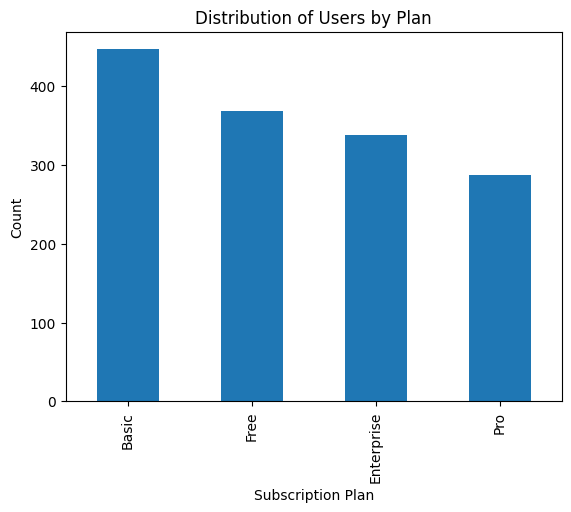

In [136]:

# Plan Distribution Visualization (single variable Graph)

fitly_df['plan'].value_counts().plot(kind='bar')
plt.title('Distribution of Users by Plan')
plt.xlabel('Subscription Plan')
plt.ylabel('Count')

plt.show()

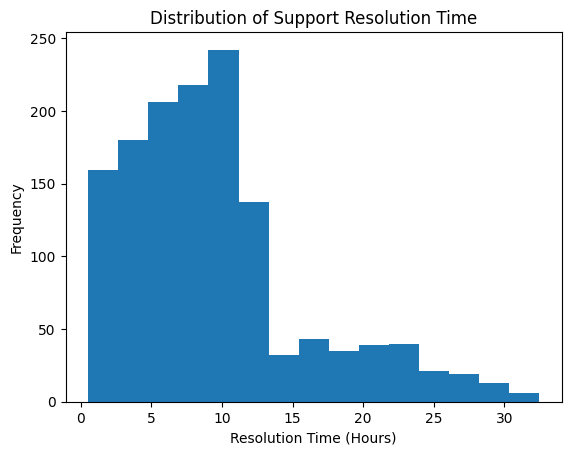

In [141]:
# Resolution Time Distribution (single variable Graph)
fitly_df['resolution_time_hours'].plot(
    kind='hist',
    bins=15
)

plt.title('Distribution of Support Resolution Time')
plt.xlabel('Resolution Time (Hours)')
plt.ylabel('Frequency')
plt.show()

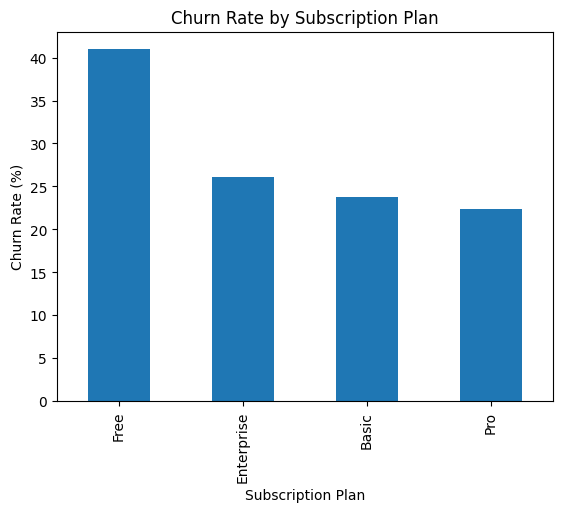

In [144]:
# Churn Rate by Subscription Plan (Multi-variable Graphic)
ax = churn_rate.sort_values(ascending=False).plot(
    kind='bar'
)

plt.title('Churn Rate by Subscription Plan')
plt.xlabel('Subscription Plan')
plt.ylabel('Churn Rate (%)')

plt.show()